# Holdout Output Demo

Use this notebook to inspect the latest TerraMind holdout predictions.

It will:
- find the latest successful run in `data/experiments/dev-run-large`
- load holdout labels and predicted GeoTIFFs
- render before/after Sentinel-2 RGB views
- show ground truth, prediction, and an error map

If you want a specific run, set `RUN_NAME` in the second code cell.

In [2]:
!python3 ../../scripts/rank_multirun_results.py  /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-sweeps-large/terramind_large_search_2026-03-12_205032/

run_name  best_epoch  best_val_loss  best_IoU  best_Accuracy  best_Precision  best_Recall  best_F1  overrides                                                                                                                                                                                   run_dir                                                                                                                                           
--------  ----------  -------------  --------  -------------  --------------  -----------  -------  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------  --------------------------------------------------------------------------------------------------------------------------------------------------
17        5           0.2555         0.6709    0.946          0.7035          0.9352       0.803    trainer.n_epochs=5; model.lear

In [1]:
!python3 ../../scripts/rank_multirun_results.py  /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-sweeps-large/terramind_large_search_2026-03-26_193723

run_name  best_epoch  best_val_loss  best_IoU  best_Accuracy  best_Precision  best_Recall  best_F1  overrides                                                                                                                                                    run_dir                                                                                                                                          
--------  ----------  -------------  --------  -------------  --------------  -----------  -------  -----------------------------------------------------------------------------------------------------------------------------------------------------------  -------------------------------------------------------------------------------------------------------------------------------------------------
5         3           1.0529         0.1975    0.793          0.4468          0.2615       0.3299   trainer.n_epochs=8; model.learning_rate=0.0005; model.num_classes=3; train_loader.num_augmenta

In [3]:
!python3 ../../scripts/rank_multirun_results.py  /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-sweeps-large/terramind_large_search_2026-03-19_190744

run_name  best_epoch  best_val_loss  best_IoU  best_Accuracy  best_Precision  best_Recall  best_F1  overrides                                                                                                                                                                                   run_dir                                                                                                                                           
--------  ----------  -------------  --------  -------------  --------------  -----------  -------  ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------  --------------------------------------------------------------------------------------------------------------------------------------------------
3         5           0.2001         0.6358    0.9379         0.6698          0.9261       0.7773   trainer.n_epochs=5; model.lear

Run directory: /users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/curriculum-learning/curriculum_terramind_2026-04-20_160535
Prediction files: 2
Holdout labels: 2


,image_id,Accuracy,Precision,Recall,F1,IoU,label_file,prediction_file
0,0,0.7509,0.2881,0.7759,0.4202,0.2660,LabelMask_B06_2019-07-28.tif,predicted_map_0_colored.tif
1,1,0.7272,0.6154,0.5739,0.5939,0.4224,LabelMask_D02_2019-05-13.tif,predicted_map_1_colored.tif


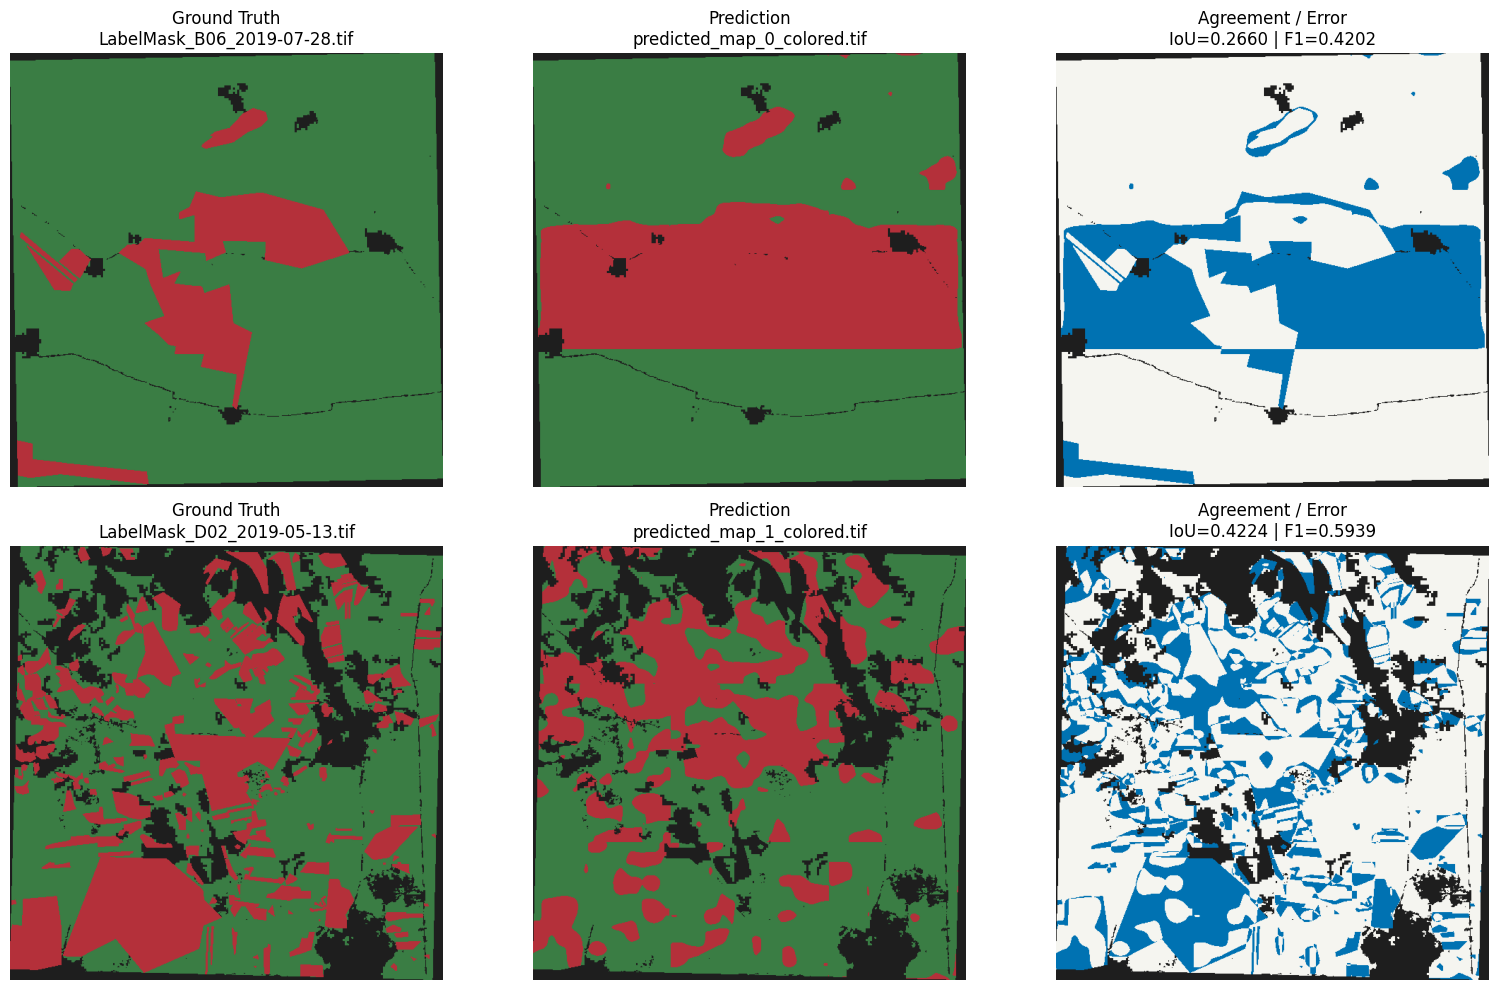

In [16]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
from IPython.display import display

PROJECT_ROOT = Path('/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2')
RUNS_DIR = PROJECT_ROOT / 'data/experiments/dev-run-large'
RUN_NAME = None  # Example: 'terramind_2026-03-11_185332'


def find_latest_run(runs_dir: Path) -> Path:
    candidates = []
    for run_dir in sorted(runs_dir.glob('terramind_*')):
        if (run_dir / 'metrics.txt').exists() and (run_dir / 'geotiffs').exists():
            candidates.append(run_dir)
    if not candidates:
        raise FileNotFoundError(f'No successful runs found in {runs_dir}')
    return candidates[-1]


# run_dir = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-sweeps-large/terramind_large_search_2026-03-12_205032/17")
# run_dir = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-sweeps-large/terramind_large_search_2026-03-26_193723/4")
# run_dir = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-sweeps-large/terramind_large_search_2026-03-27_161634-best-ce-run2/2")
# run_dir = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/dev-run-large/terramind_2026-03-27_193712-best-ep3-ce")
run_dir = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/curriculum-learning/curriculum_terramind_2026-04-20_160535")
# run_dir = Path("/users/PGS0218/julina/projects/geography/damage_mapping_terramind/V2/data/experiments/Prithvi_Encoder/terramind_2026-04-11_010331")
# holdout_before_dir = PROJECT_ROOT / 'data/input/flood_data/Train/Before/S2L2A'
# holdout_after_dir = PROJECT_ROOT / 'data/input/flood_data/Train/After/S2L2A'
# holdout_label_dir = PROJECT_ROOT / 'data/input/flood_data/Train/Labels'


# run_dir = RUNS_DIR / RUN_NAME if RUN_NAME else find_latest_run(RUNS_DIR)
pred_dir = run_dir / 'geotiffs'
holdout_before_dir = PROJECT_ROOT / 'data/input/Images_large/Test/Before/S2L2A'
holdout_after_dir = PROJECT_ROOT / 'data/input/Images_large/Test/After/S2L2A'
holdout_label_dir = PROJECT_ROOT / 'data/input/Images_large/Test/Labels'

pred_files = sorted(pred_dir.glob('predicted_map_*_colored.tif'))
label_files = sorted(holdout_label_dir.glob('*.tif'))
before_files = sorted(holdout_before_dir.glob('*.tif'))
after_files = sorted(holdout_after_dir.glob('*.tif'))

print(f'Run directory: {run_dir}')
print(f'Prediction files: {len(pred_files)}')
print(f'Holdout labels: {len(label_files)}')
assert len(pred_files) == len(label_files) == len(before_files) == len(after_files), 'Holdout file counts do not match.'

CLASS_NAMES = {
    0: 'background',
    1: 'no_damage',
    2: 'damage',
}

CLASS_COLORS = {
    0: np.array([30, 30, 30], dtype=np.uint8),
    1: np.array([58, 125, 68], dtype=np.uint8),
    2: np.array([180, 48, 58], dtype=np.uint8),
}

ERROR_COLORS = {
    0: np.array([30, 30, 30], dtype=np.uint8),
    1: np.array([245, 245, 240], dtype=np.uint8),
    2: np.array([0, 114, 178], dtype=np.uint8),
}


def parse_metrics(metrics_path: Path) -> pd.DataFrame:
    text = metrics_path.read_text()
    pattern = re.compile(
        r'Image\s+(?P<image_id>\d+)\s+metrics:\s+'
        r'Accuracy:\s+(?P<Accuracy>[0-9.]+)\s+'
        r'Precision:\s+(?P<Precision>[0-9.]+)\s+'
        r'Recall:\s+(?P<Recall>[0-9.]+)\s+'
        r'F1:\s+(?P<F1>[0-9.]+)\s+'
        r'IoU:\s+(?P<IoU>[0-9.]+)',
        re.MULTILINE,
    )
    records = []
    for match in pattern.finditer(text):
        row = match.groupdict()
        row['image_id'] = int(row['image_id'])
        for key in ('Accuracy', 'Precision', 'Recall', 'F1', 'IoU'):
            row[key] = float(row[key])
        records.append(row)
    df = pd.DataFrame(records).sort_values('image_id').reset_index(drop=True)
    return df


def read_single_band(path: Path) -> np.ndarray:
    with rio.open(path) as src:
        return src.read(1)


def colorize_labels(label: np.ndarray, color_table: dict[int, np.ndarray]) -> np.ndarray:
    rgb = np.zeros(label.shape + (3,), dtype=np.uint8)
    for cls, color in color_table.items():
        rgb[label == cls] = color
    return rgb


def build_error_map(truth: np.ndarray, pred: np.ndarray) -> np.ndarray:
    error = np.zeros_like(truth, dtype=np.uint8)
    valid = truth != 0
    error[valid & (truth == pred)] = 1
    error[valid & (truth != pred)] = 2
    return colorize_labels(error, ERROR_COLORS)


metrics_df = parse_metrics(run_dir / 'metrics.txt')
metrics_df['label_file'] = [path.name for path in label_files]
metrics_df['prediction_file'] = [path.name for path in pred_files]
display(metrics_df)

n_tiles = len(pred_files)
fig, axes = plt.subplots(n_tiles, 3, figsize=(16, 5 * n_tiles))
if n_tiles == 1:
    axes = np.expand_dims(axes, axis=0)

for tile_idx in range(n_tiles):
    label = read_single_band(label_files[tile_idx]).astype(np.uint8)
    prediction = read_single_band(pred_files[tile_idx]).astype(np.uint8)
    label_rgb = colorize_labels(label, CLASS_COLORS)
    prediction_rgb = colorize_labels(prediction, CLASS_COLORS)
    error_rgb = build_error_map(label, prediction)
    row = metrics_df.iloc[tile_idx]

    panels = [label_rgb, prediction_rgb, error_rgb]
    titles = [
        f'Ground Truth\n{label_files[tile_idx].name}',
        f'Prediction\n{pred_files[tile_idx].name}',
        f'Agreement / Error\nIoU={row.IoU:.4f} | F1={row.F1:.4f}',
    ]

    for col_idx, (panel, title) in enumerate(zip(panels, titles)):
        axes[tile_idx, col_idx].imshow(panel)
        axes[tile_idx, col_idx].set_title(title)
        axes[tile_idx, col_idx].axis('off')

plt.tight_layout()
# plt.savefig('dice_ep5.png')
plt.show()

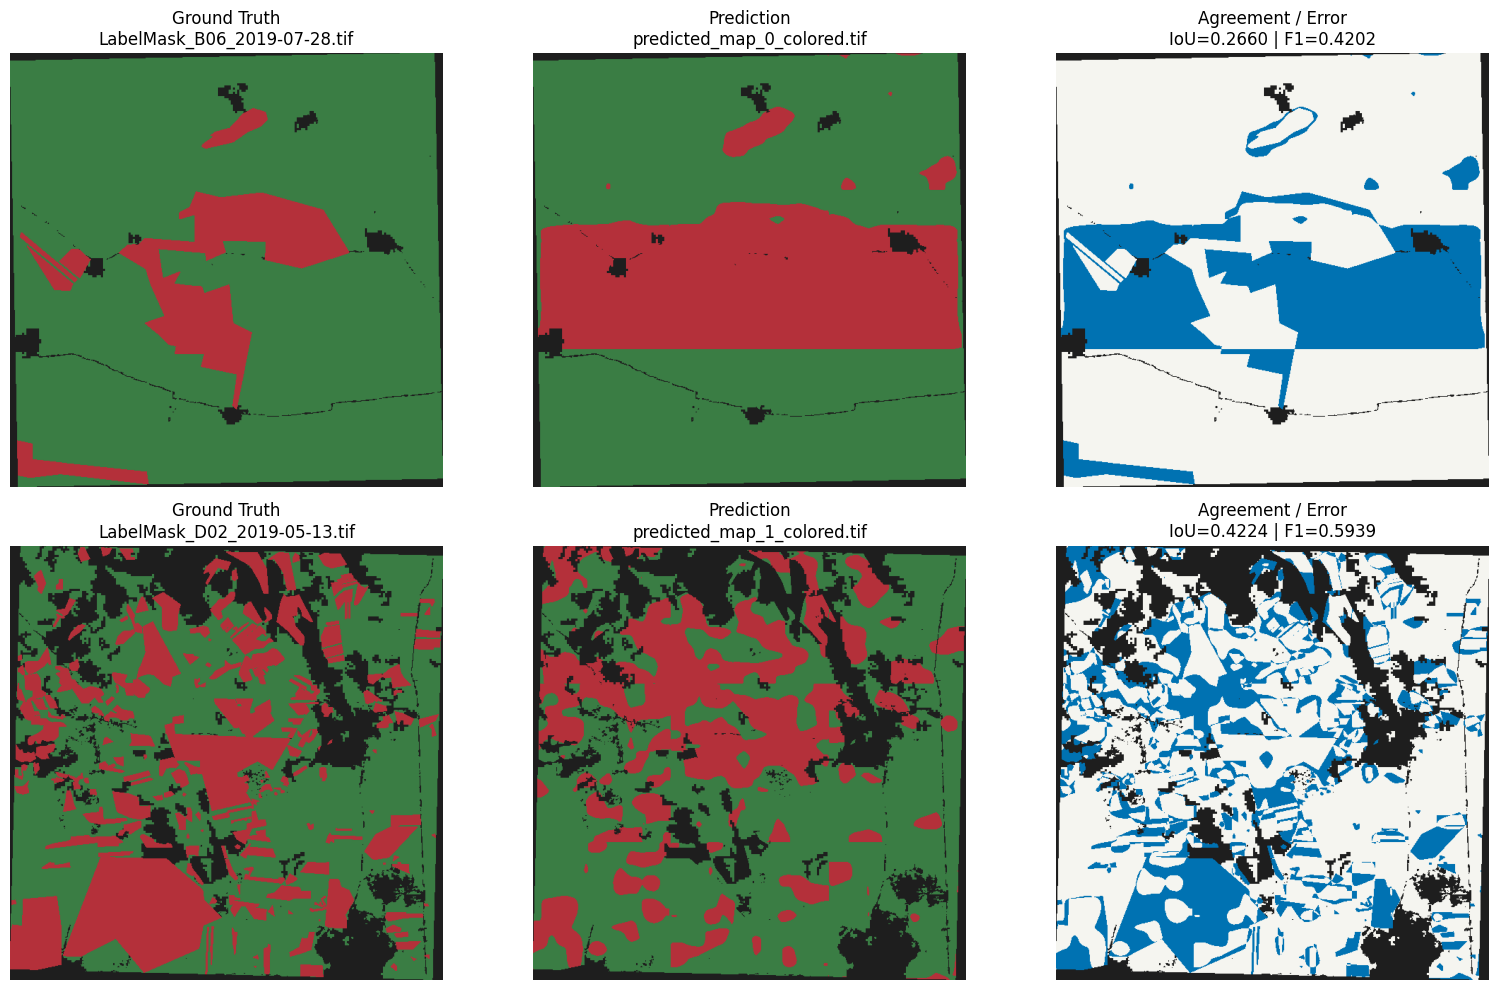

In [15]:
n_tiles = len(pred_files)
fig, axes = plt.subplots(n_tiles, 3, figsize=(16, 5 * n_tiles))
if n_tiles == 1:
    axes = np.expand_dims(axes, axis=0)

for tile_idx in range(n_tiles):
    label = read_single_band(label_files[tile_idx]).astype(np.uint8)
    prediction = read_single_band(pred_files[tile_idx]).astype(np.uint8)
    label_rgb = colorize_labels(label, CLASS_COLORS)
    prediction_rgb = colorize_labels(prediction, CLASS_COLORS)
    error_rgb = build_error_map(label, prediction)
    row = metrics_df.iloc[tile_idx]

    panels = [label_rgb, prediction_rgb, error_rgb]
    titles = [
        f'Ground Truth\n{label_files[tile_idx].name}',
        f'Prediction\n{pred_files[tile_idx].name}',
        f'Agreement / Error\nIoU={row.IoU:.4f} | F1={row.F1:.4f}',
    ]

    for col_idx, (panel, title) in enumerate(zip(panels, titles)):
        axes[tile_idx, col_idx].imshow(panel)
        axes[tile_idx, col_idx].set_title(title)
        axes[tile_idx, col_idx].axis('off')

plt.tight_layout()
# plt.savefig('dice_ep5.png')
plt.show()